## Tujuan Modeling
Notebook ini membangun dan mengevaluasi model klasifikasi churn menggunakan data hasil preprocessing.

Tahapan:
1. Load data train-test hasil preprocessing
2. Train baseline model (Logistic Regression)
3. Evaluasi metrik churn (Recall, Precision, F1, ROC-AUC, Confusion Matrix)
4. Bandingkan dengan model tree-based (Random Forest + optional XGBoost/LightGBM)
5. Tuning hyperparameter model terbaik
6. Analisis feature importance/koefisien
7. Simpan model final

In [1]:
# Import library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve
)

import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Optional model: XGBoost / LightGBM
has_xgb = False
has_lgbm = False

try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception:
    print("XGBoost tidak tersedia, akan dilewati.")

try:
    from lightgbm import LGBMClassifier
    has_lgbm = True
except Exception:
    print("LightGBM tidak tersedia, akan dilewati.")

print(f"XGBoost available: {has_xgb}")
print(f"LightGBM available: {has_lgbm}")

XGBoost available: True
LightGBM available: True


In [3]:
# Load data hasil preprocessing
X_train_full = pd.read_csv("../dataset/processed/X_train.csv")
X_test = pd.read_csv("../dataset/processed/X_test.csv")

y_train_full = pd.read_csv("../dataset/processed/y_train.csv").iloc[:, 0]
y_test = pd.read_csv("../dataset/processed/y_test.csv").iloc[:, 0]

print("Shape data:")
print("X_train_full:", X_train_full.shape)
print("X_test      :", X_test.shape)
print("y_train_full:", y_train_full.shape)
print("y_test      :", y_test.shape)

print("\nDistribusi target train_full (%):")
print(y_train_full.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target test (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("\nShape split:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nDistribusi target train (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target val (%):")
print(y_val.value_counts(normalize=True).mul(100).round(2))

Shape data:
X_train_full: (5625, 35)
X_test      : (1407, 35)
y_train_full: (5625,)
y_test      : (1407,)

Distribusi target train_full (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Distribusi target test (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Shape split:
X_train: (4500, 35)
X_val  : (1125, 35)
X_test : (1407, 35)

Distribusi target train (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Distribusi target val (%):
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


## Helper Function Evaluasi
Fungsi ini menghitung metrik utama churn dan menampilkan confusion matrix + ROC curve.

In [4]:
def evaluate_model(model, X_fit, y_fit, X_eval, y_eval, model_name="Model", threshold=0.5, show_plot=True):
    model.fit(X_fit, y_fit)

    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba),
    }

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        cm = confusion_matrix(y_eval, y_pred)
        ConfusionMatrixDisplay(cm).plot(ax=axes[0], colorbar=False)
        axes[0].set_title(f"Confusion Matrix - {model_name}")

        RocCurveDisplay.from_predictions(y_eval, y_proba, ax=axes[1])
        axes[1].set_title(f"ROC Curve - {model_name}")

        plt.tight_layout()
        plt.show()

    return metrics, model

## Baseline 1: Logistic Regression
Sebagai baseline sederhana dan interpretable.

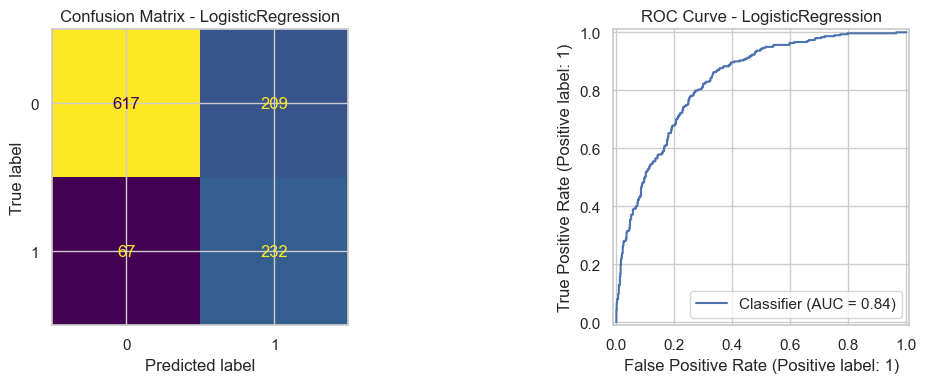

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.5,0.7547,0.5261,0.7759,0.627,0.8359


In [5]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=3000,
    class_weight="balanced"
)

logreg_metrics, logreg_fitted = evaluate_model(
    model=logreg,
    X_fit=X_train,
    y_fit=y_train,
    X_eval=X_val,
    y_eval=y_val,
    model_name="LogisticRegression",
    threshold=0.5,
    show_plot=True
)

pd.DataFrame([logreg_metrics]).round(4)

## Tree-Based Models
Bandingkan dengan Random Forest, lalu optional XGBoost/LightGBM jika tersedia.

In [6]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
}

if has_xgb:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss"
    )

if has_lgbm:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42
    )

results = [logreg_metrics]
fitted_models = {"LogisticRegression": logreg_fitted}

for name, mdl in models.items():
    m, fitted = evaluate_model(
        model=mdl,
        X_fit=X_train,
        y_fit=y_train,
        X_eval=X_val,
        y_eval=y_val,
        model_name=name,
        threshold=0.5,
        show_plot=False
    )
    results.append(m)
    fitted_models[name] = fitted

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["recall", "f1", "roc_auc"],
    ascending=False
).reset_index(drop=True)

display(results_df.round(4))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1196, number of negative: 3304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 4500, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151


,model,threshold,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.5,0.7547,0.5261,0.7759,0.6270,0.8359
1,LightGBM,0.5,0.7778,0.6000,0.4916,0.5404,0.8113
2,XGBoost,0.5,0.7778,0.6025,0.4816,0.5353,0.8190
3,RandomForest,0.5,0.7733,0.5982,0.4482,0.5124,0.8169


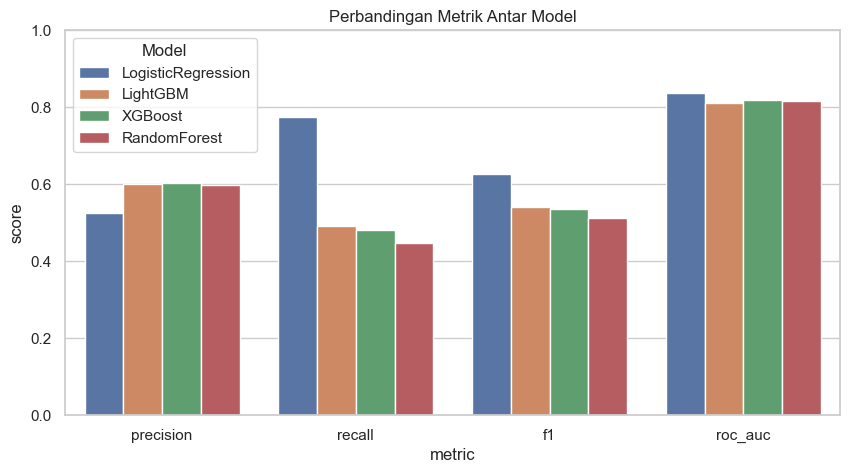

In [7]:
# Visual perbandingan metrik utama
metric_cols = ["precision", "recall", "f1", "roc_auc"]

plot_df = results_df.melt(
    id_vars="model",
    value_vars=metric_cols,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Perbandingan Metrik Antar Model")
plt.legend(title="Model")
plt.show()

## Pilih Model Terbaik dan Tuning
Prioritas churn biasanya Recall dan F1. Di sini dipakai skor F1 sebagai default.

In [8]:
best_row = results_df.iloc[0]
best_model_name = best_row["model"]

print("Model terbaik sebelum tuning:", best_model_name)
print(best_row[["precision", "recall", "f1", "roc_auc"]].round(4))

base_model = fitted_models[best_model_name]

Model terbaik sebelum tuning: LogisticRegression
precision    0.5261
recall       0.7759
f1            0.627
roc_auc      0.8359
Name: 0, dtype: object


In [9]:
# Hyperparameter tuning sesuai model terbaik
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_model_name == "LogisticRegression":
    param_dist = {
        "C": np.logspace(-3, 2, 20),
        "solver": ["liblinear", "lbfgs"]
    }
    tuner = RandomizedSearchCV(
        estimator=LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ),
        param_distributions=param_dist,
        n_iter=20,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

elif best_model_name == "RandomForest":
    param_dist = {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [None, 5, 8, 12, 16],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
        "class_weight": ["balanced", "balanced_subsample"]
    }
    tuner = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=25,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

elif best_model_name == "XGBoost":
    param_dist = {
        "n_estimators": [200, 400, 600],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5]
    }
    tuner = RandomizedSearchCV(
        estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
        param_distributions=param_dist,
        n_iter=25,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

elif best_model_name == "LightGBM":
    param_dist = {
        "n_estimators": [200, 400, 600],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [-1, 5, 8, 12],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    }
    tuner = RandomizedSearchCV(
        estimator=LGBMClassifier(random_state=42),
        param_distributions=param_dist,
        n_iter=25,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

with joblib.parallel_backend("threading"):
    tuner.fit(X_train, y_train)

best_tuned_model = tuner.best_estimator_
print("Best params:", tuner.best_params_)
print("Best CV F1:", round(tuner.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'solver': 'liblinear', 'C': np.float64(1.438449888287663)}
Best CV F1: 0.6351


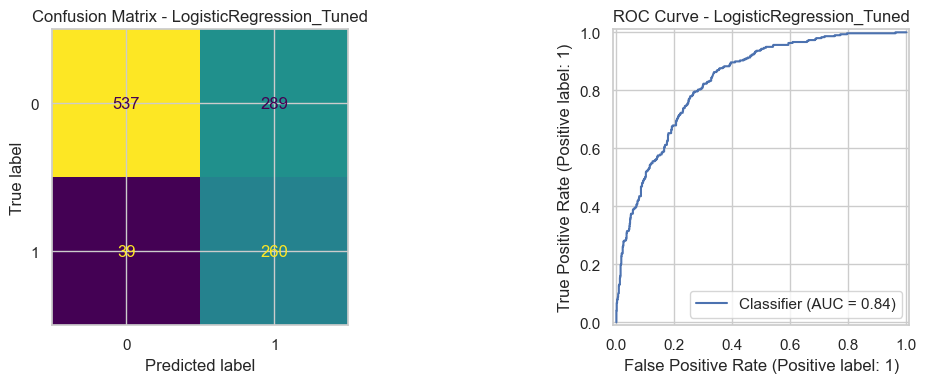

,model,precision,recall,f1,roc_auc
0,LogisticRegression,0.5261,0.7759,0.6270,0.8359
1,LogisticRegression_Tuned,0.4736,0.8696,0.6132,0.8359


In [10]:
# Evaluasi tuned model di test set (threshold default 0.5)
tuned_metrics, tuned_fitted = evaluate_model(
    model=best_tuned_model,
    X_fit=X_train,
    y_fit=y_train,
    X_eval=X_val,
    y_eval=y_val,
    model_name=f"{best_model_name}_Tuned",
    threshold=0.4,
    show_plot=True
)

compare_before_after = pd.DataFrame([
    best_row.to_dict(),
    tuned_metrics
])

display(compare_before_after[["model", "precision", "recall", "f1", "roc_auc"]].round(4))

## Threshold Tuning
Tujuan: menaikkan Recall tanpa menjatuhkan Precision terlalu jauh.

Best threshold by PR-F1: 0.496
Precision: 0.526
Recall   : 0.7793
F1       : 0.628


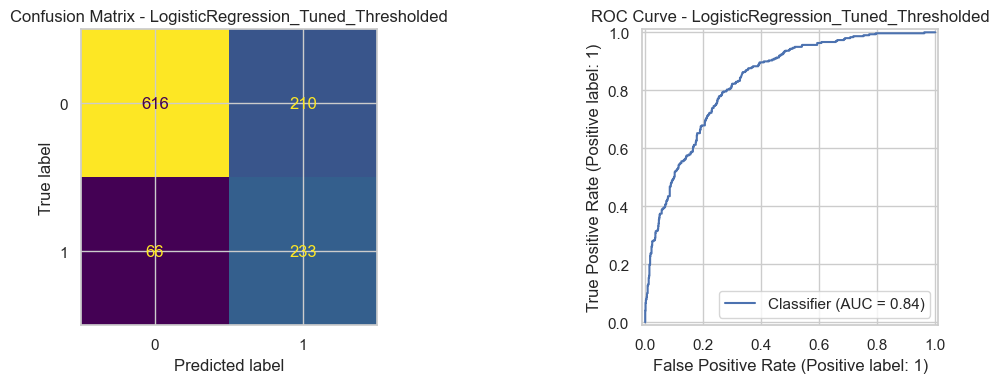

In [11]:
# Cari threshold terbaik berdasarkan F1
y_proba_val = tuned_fitted.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, y_proba_val)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thr[best_idx]

print("Best threshold by PR-F1:", round(float(best_threshold), 4))
print("Precision:", round(float(prec[best_idx]), 4))
print("Recall   :", round(float(rec[best_idx]), 4))
print("F1       :", round(float(f1_scores[best_idx]), 4))

_ = evaluate_model(
    model=tuned_fitted,
    X_fit=X_train,
    y_fit=y_train,
    X_eval=X_val,
    y_eval=y_val,
    model_name=f"{best_model_name}_Tuned_Thresholded",
    threshold=float(best_threshold),
    show_plot=True
)

## Feature Importance / Koefisien
- Logistic Regression: gunakan koefisien
- Tree-based: gunakan feature_importances_

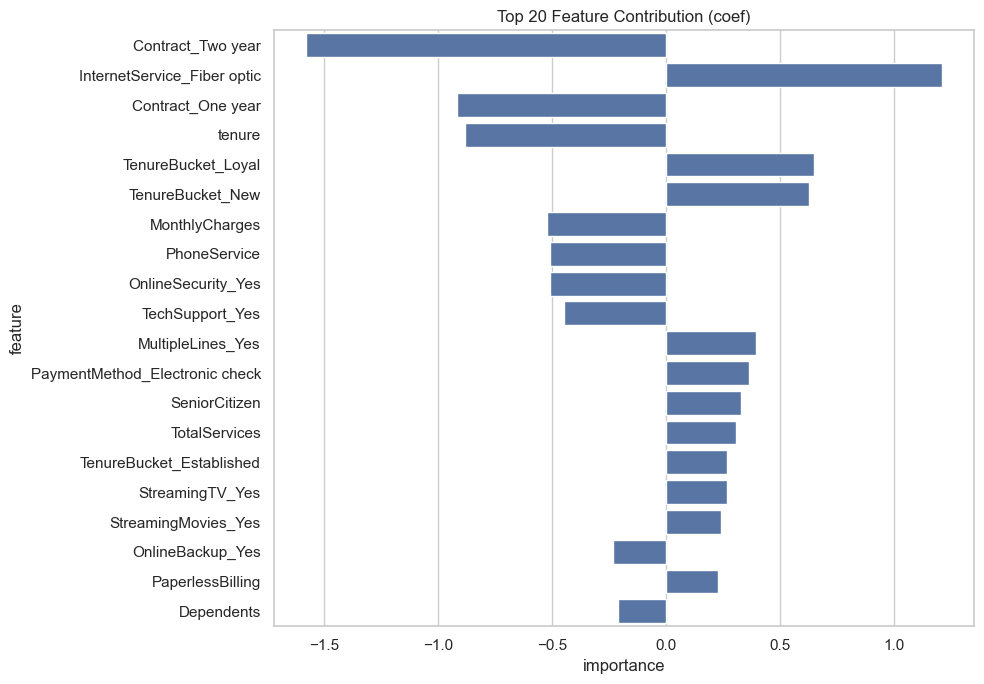

,feature,importance,abs_importance
28,Contract_Two year,-1.580015,1.580015
13,InternetService_Fiber optic,1.209949,1.209949
27,Contract_One year,-0.916952,0.916952
3,tenure,-0.883079,0.883079
33,TenureBucket_Loyal,0.646673,0.646673
34,TenureBucket_New,0.624312,0.624312
6,MonthlyCharges,-0.520974,0.520974
4,PhoneService,-0.511219,0.511219
16,OnlineSecurity_Yes,-0.511105,0.511105
22,TechSupport_Yes,-0.446877,0.446877


In [12]:
def get_feature_contribution(model, feature_names):
    if hasattr(model, "coef_"):
        coef = model.coef_.ravel()
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": coef,
            "abs_importance": np.abs(coef)
        }).sort_values("abs_importance", ascending=False)
        return imp_df, "coef"

    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
        imp_df = pd.DataFrame({
            "feature": feature_names,
            "importance": imp,
            "abs_importance": np.abs(imp)
        }).sort_values("abs_importance", ascending=False)
        return imp_df, "importance"

    raise ValueError("Model tidak punya coef_ atau feature_importances_.")

imp_df, imp_type = get_feature_contribution(tuned_fitted, X_train.columns)

top_n = 20
top_imp = imp_df.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_imp, y="feature", x="importance")
plt.title(f"Top {top_n} Feature Contribution ({imp_type})")
plt.tight_layout()
plt.show()

display(imp_df.head(20))

## Insight Bisnis Singkat
Isi poin insight dari top feature:

1. Fitur yang paling berpengaruh meningkatkan peluang churn adalah TenureBucket_New, InternetService_Fiber optic, AvgMonthlyCharges, SeniorCitizen, dan MonthlyCharges.

2. Fitur yang paling berpengaruh menurunkan peluang churn adalah Contract_Two year, tenure, Contract_One year, OnlineSecurity_Yes, PhoneService, TechSupport_Yes, TotalServices, dan Dependents.

3. Implikasi aksi retention:
- Prioritaskan customer dengan tenure rendah dan kontrak month-to-month untuk intervensi lebih awal.
- Berikan penawaran khusus untuk pengguna fiber optic dan electronic check karena kelompok ini cenderung lebih berisiko churn.
- Dorong kontrak jangka panjang melalui diskon atau bundling.
- Tingkatkan kualitas layanan tambahan seperti OnlineSecurity dan TechSupport karena fitur ini cenderung menurunkan churn.

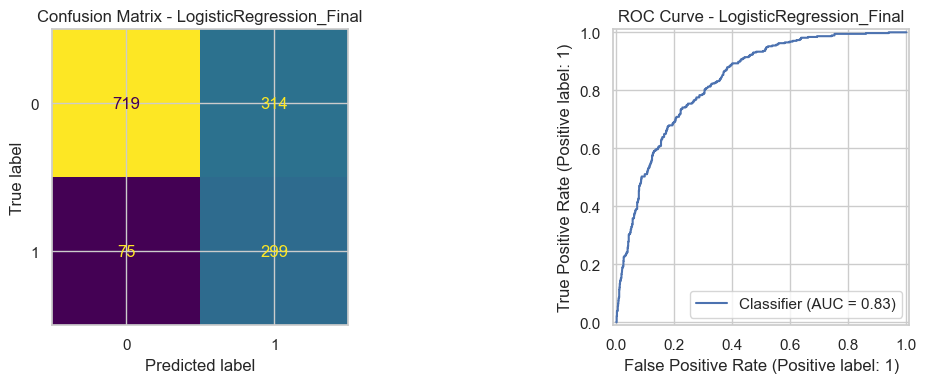

,model,threshold,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression_Final,0.496,0.7235,0.4878,0.7995,0.6059,0.8342


Model artifact disimpan di ../models/churn_model.joblib


In [13]:
# Evaluasi final pada test set
final_model = tuned_fitted
final_threshold = float(best_threshold)

test_metrics, final_model_fitted = evaluate_model(
    model=final_model,
    X_fit=pd.concat([X_train, X_val], axis=0),
    y_fit=pd.concat([y_train, y_val], axis=0),
    X_eval=X_test,
    y_eval=y_test,
    model_name=f"{best_model_name}_Final",
    threshold=final_threshold,
    show_plot=True
)

display(pd.DataFrame([test_metrics]).round(4))

artifact = {
    "model": final_model_fitted,
    "threshold": final_threshold,
    "feature_names": X_train.columns.tolist()
}

joblib.dump(artifact, "../models/churn_model.joblib")
print("Model artifact disimpan di ../models/churn_model.joblib")